In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

store = pd.read_csv('../dataset/store.csv')
train = pd.read_csv('../dataset/train.csv', low_memory=False)

df = train.merge(store, on="Store", how="left")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

In [2]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
Id                                0
StoreType                         0
Assortment                        0
CompetitionDistance            2600
CompetitionOpenSinceMonth    318392
CompetitionOpenSinceYear     318392
Promo2                            0
Promo2SinceWeek              500415
Promo2SinceYear              500415
PromoInterval                500415
dtype: int64

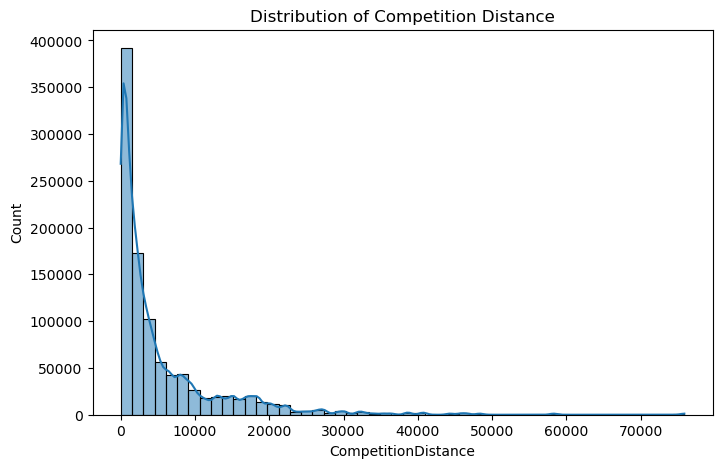

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df["CompetitionDistance"].dropna(), bins=50, kde=True)
plt.title("Distribution of Competition Distance")
plt.show()

In [4]:
# Replacing the null for CompetitionDistance using median because retail distances are skewed
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())

In [5]:
# Making an extra feature where we are updating the values using CompetitionOpenSinceYear and populating all null values by 0
df["CompetitionOpen"] = df["CompetitionOpenSinceYear"].notnull().astype(int)
df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(0)
df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)

In [6]:
df["Promo2"].value_counts()

Promo2
1    501184
0    500415
Name: count, dtype: int64

In [7]:
# These are structurally missing because the store was not participating in long-term promotions. Dropping them would remove important business signal.
df["IsPromo2Active"] = df["Promo2"]
df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)
df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)
df["PromoInterval"] = df["PromoInterval"].fillna("None")

In [8]:
df.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
Id                           0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
CompetitionOpen              0
IsPromo2Active               0
dtype: int64

In [9]:
# Removing the closed stores
df = df[df["Open"] == 1]

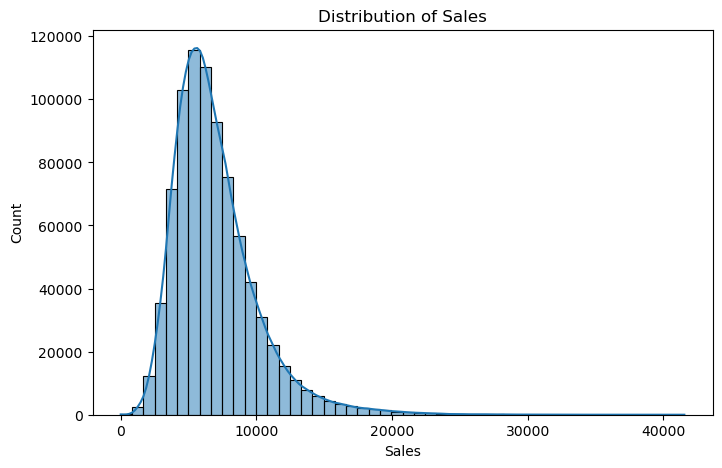

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=50, kde=True)
plt.title("Distribution of Sales")
plt.show()

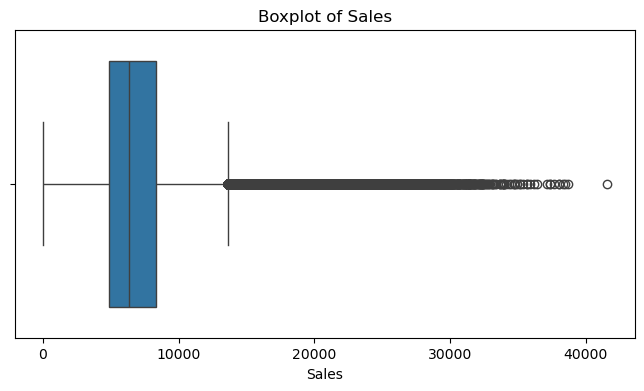

In [11]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Sales"])
plt.title("Boxplot of Sales")
plt.show()

In [12]:
df["Sales"].skew()

np.float64(1.595831393352442)

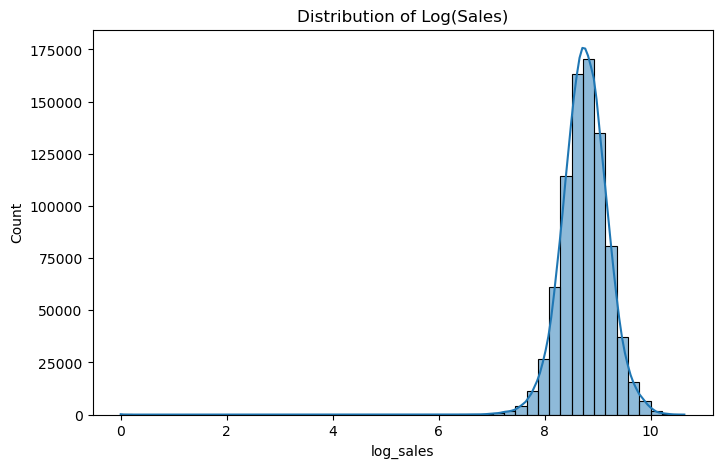

In [13]:
# Sales distribution is heavily right-skewed. Log transformation stabilizes variance and makes linear modeling assumptions more appropriate.
import numpy as np

df["log_sales"] = np.log1p(df["Sales"])

plt.figure(figsize=(8,5))
sns.histplot(df["log_sales"], bins=50, kde=True)
plt.title("Distribution of Log(Sales)")
plt.show()

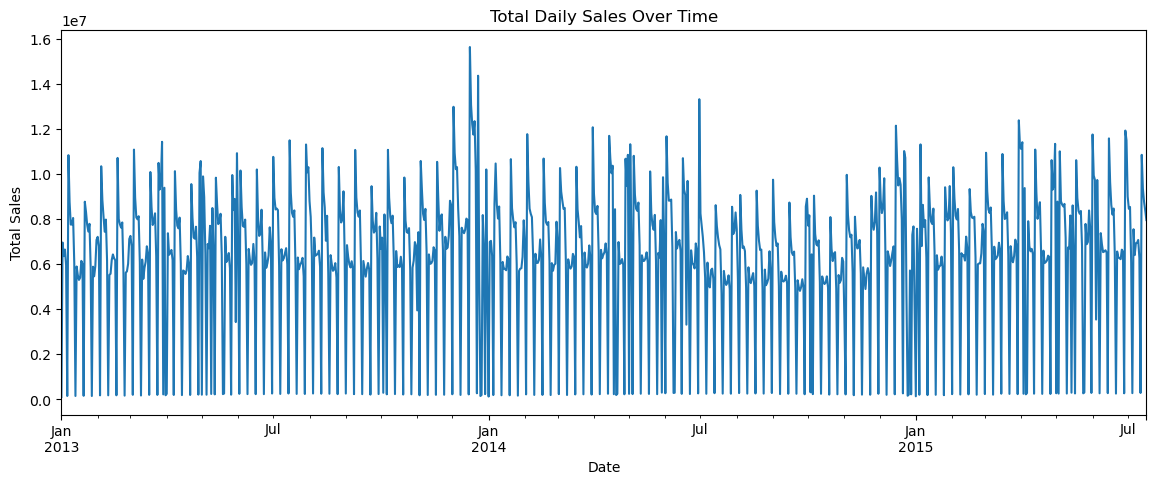

In [14]:
daily_sales = df.groupby("Date")["Sales"].sum()

plt.figure(figsize=(14,5))
daily_sales.plot()
plt.title("Total Daily Sales Over Time")
plt.ylabel("Total Sales")
plt.show()

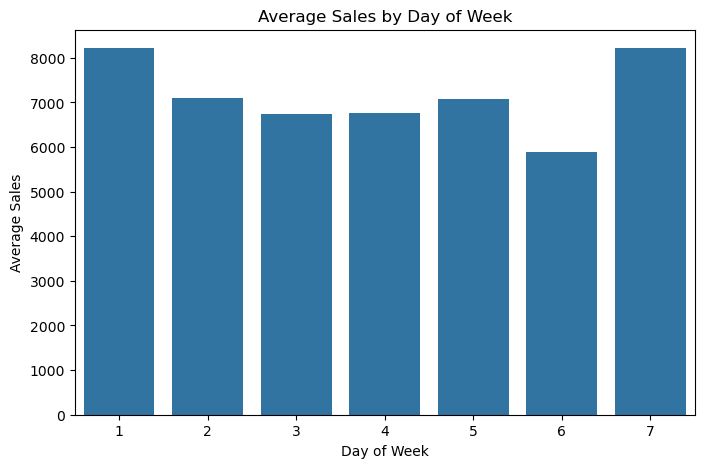

In [15]:
# Clear weekly seasonality observed. Sales vary significantly by day of week, indicating need for seasonal features in modeling.
weekly_sales = df.groupby("DayOfWeek")["Sales"].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=weekly_sales.index, y=weekly_sales.values)
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.show()

In [16]:
df.groupby("Promo")["Sales"].mean()

Promo
0    5930.334374
1    8224.401849
Name: Sales, dtype: float64

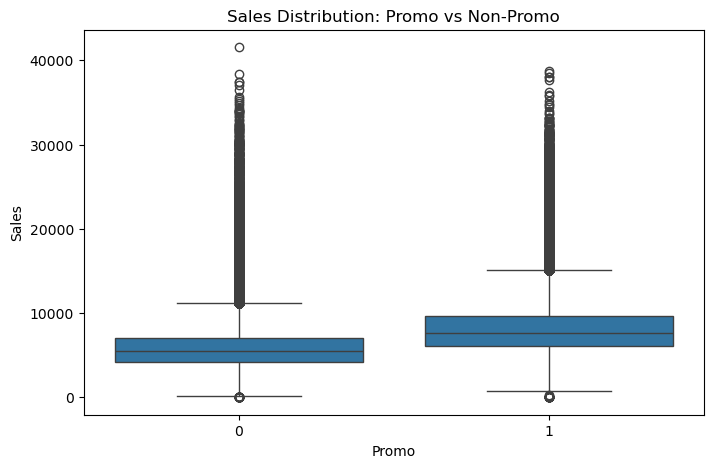

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Promo", y="Sales", data=df)
plt.title("Sales Distribution: Promo vs Non-Promo")
plt.show()

In [18]:
# Promotions increase average sales by X%, indicating strong demand sensitivity to pricing incentives.
promo_mean = df[df["Promo"] == 1]["Sales"].mean()
nonpromo_mean = df[df["Promo"] == 0]["Sales"].mean()

uplift = (promo_mean - nonpromo_mean) / nonpromo_mean * 100
print(f"Promotion increases sales by approximately {uplift:.2f}%")

Promotion increases sales by approximately 38.68%


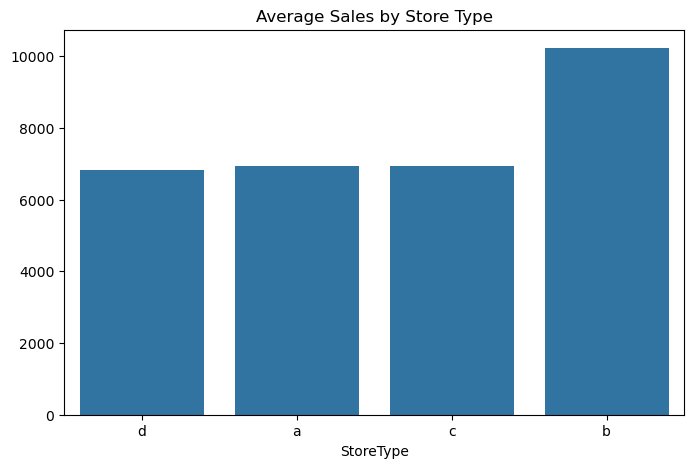

In [19]:
# Significant variation observed across store types, suggesting store-level characteristics influence demand and should be encoded in modeling.
store_type_sales = df.groupby("StoreType")["Sales"].mean().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=store_type_sales.index, y=store_type_sales.values)
plt.title("Average Sales by Store Type")
plt.show()

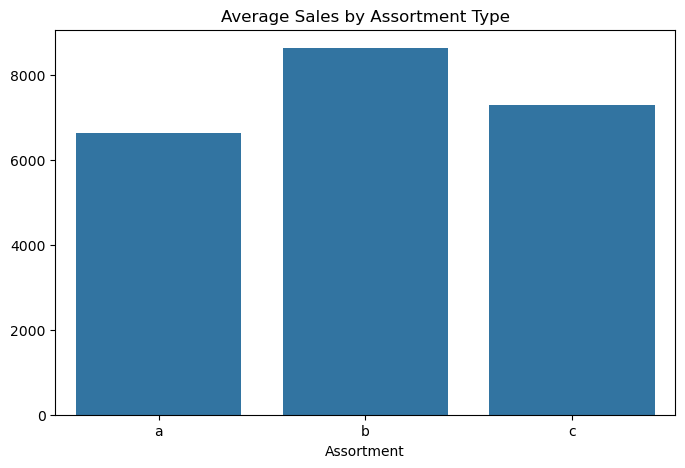

In [20]:
# Extended assortment stores usually sell more.
assortment_sales = df.groupby("Assortment")["Sales"].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=assortment_sales.index, y=assortment_sales.values)
plt.title("Average Sales by Assortment Type")
plt.show()

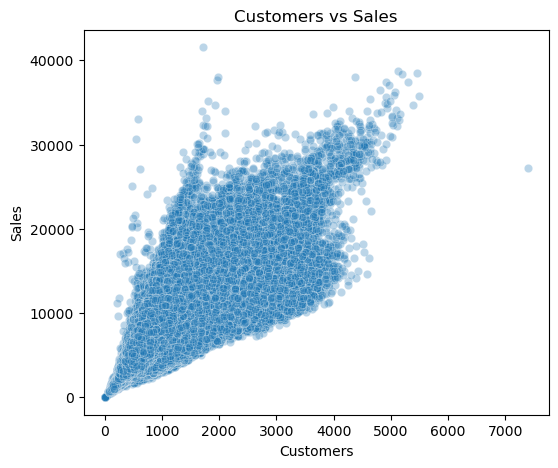

In [21]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="Customers", y="Sales", data=df, alpha=0.3)
plt.title("Customers vs Sales")
plt.show()

In [22]:
# Strong positive correlation between customer and sales confirms volume-driven revenue structure.
df[["Customers", "Sales"]].corr()

,Customers,Sales
Customers,1.000000,0.824077
Sales,0.824077,1.000000


In [23]:
df.groupby("StateHoliday")["Sales"].mean()

StateHoliday
0    6953.437611
a    8487.471182
b    9887.889655
c    9743.746479
Name: Sales, dtype: float64

<Axes: xlabel='StateHoliday', ylabel='Sales'>

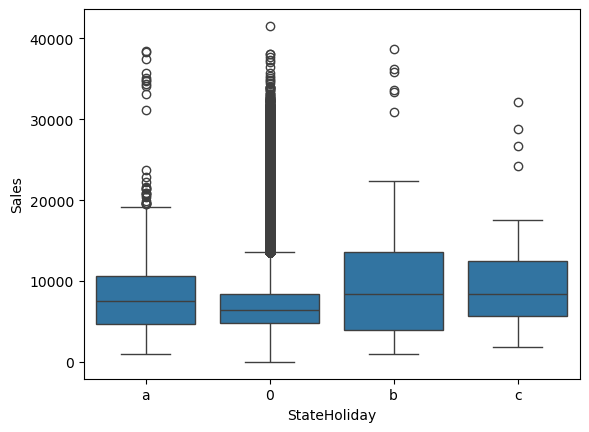

In [24]:
sns.boxplot(x="StateHoliday", y="Sales", data=df)

In [25]:
# Holiday periods demonstrate noticeable variation in sales, reinforcing the importance of calendar-based features in forecasting.
df.groupby("SchoolHoliday")["Sales"].mean()

SchoolHoliday
0    6901.445672
1    7190.114678
Name: Sales, dtype: float64

In [26]:
# Stores with closer competitors show different sales dynamics, suggesting competitive pressure influences performance.
df["comp_bin"] = pd.qcut(df["CompetitionDistance"], 4)

df.groupby("comp_bin")["Sales"].mean()

/var/folders/l0/6hl39xhs6hgg4hz639lg4r980000gn/T/ipykernel_35525/4178385765.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("comp_bin")["Sales"].mean()


comp_bin
(19.999, 710.0]      7360.113574
(710.0, 2330.0]      6892.043755
(2330.0, 6880.0]     6729.254962
(6880.0, 75860.0]    6837.044169
Name: Sales, dtype: float64

In [27]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

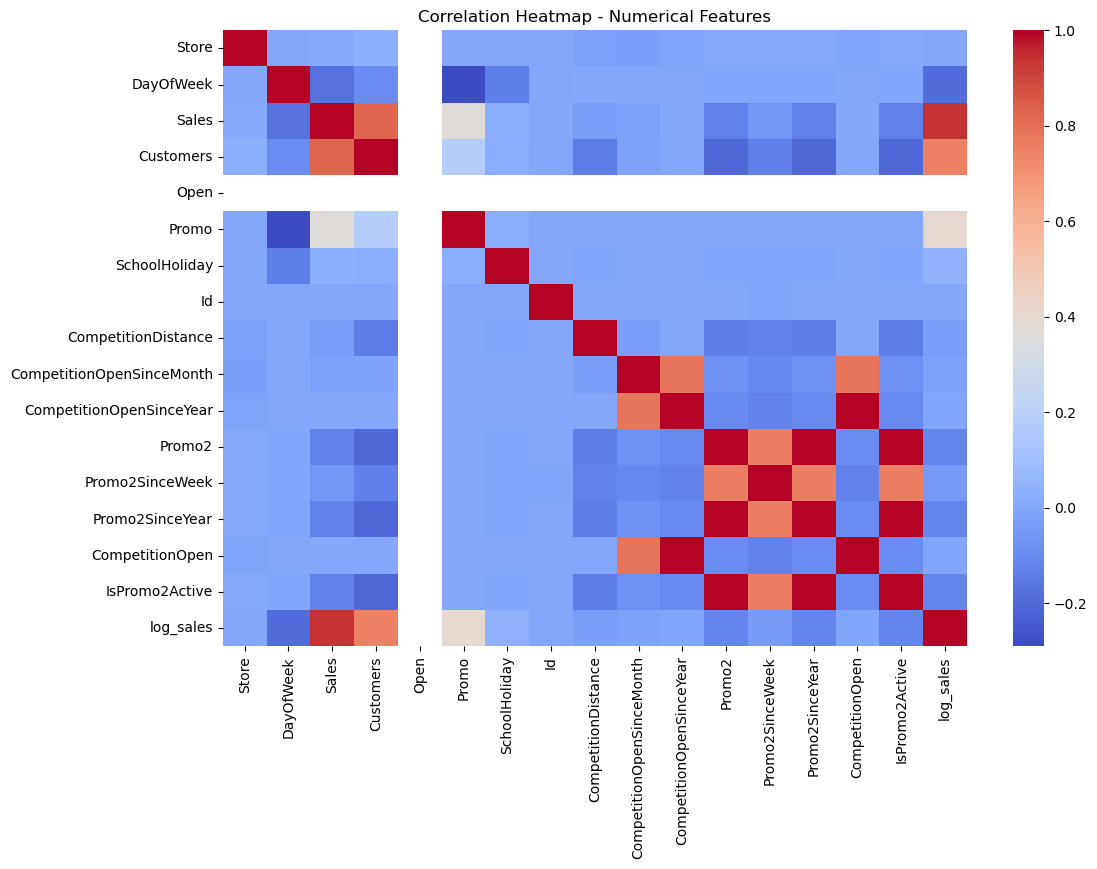

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), 
            cmap="coolwarm", 
            annot=False)
plt.title("Correlation Heatmap - Numerical Features")
plt.show()

In [29]:
df[numeric_cols].corr()["Sales"].sort_values(ascending=False)

Sales                        1.000000
log_sales                    0.936438
Customers                    0.824077
Promo                        0.367183
SchoolHoliday                0.036247
Store                        0.007783
CompetitionOpenSinceYear     0.005692
CompetitionOpen              0.005621
Id                           0.000817
CompetitionOpenSinceMonth   -0.018046
CompetitionDistance         -0.036738
Promo2SinceWeek             -0.058901
Promo2                      -0.127988
IsPromo2Active              -0.127988
Promo2SinceYear             -0.128014
DayOfWeek                   -0.178995
Open                              NaN
Name: Sales, dtype: float64

In [30]:
corr_matrix = df[numeric_cols].corr().abs()

high_corr = (
    corr_matrix.where(corr_matrix > 0.8)
               .stack()
               .reset_index()
)

high_corr = high_corr[high_corr["level_0"] != high_corr["level_1"]]
high_corr

,level_0,level_1,0
3,Sales,Customers,0.824077
4,Sales,log_sales,0.936438
5,Customers,Sales,0.824077
13,CompetitionOpenSinceYear,CompetitionOpen,0.999986
15,Promo2,Promo2SinceYear,0.999999
16,Promo2,IsPromo2Active,1.000000
18,Promo2SinceYear,Promo2,0.999999
20,Promo2SinceYear,IsPromo2Active,0.999999
21,CompetitionOpen,CompetitionOpenSinceYear,0.999986
23,IsPromo2Active,Promo2,1.000000


## Correlation & Multicollinearity Findings:

- Customers exhibit strong correlation (0.82) with Sales and will be excluded to prevent data leakage.

- Promotion has meaningful positive correlation, supporting inclusion in elasticity modeling.

- Competition features show weak linear correlation but may capture store-level effects.

- Some long-term promotion features are redundant and will be reduced to avoid multicollinearity.

- Regularization (Ridge/ElasticNet) will be used to handle correlated lag features.

# Feature Engineering



Seperating the Year and week and grouping all data accordingly

In [31]:
df["Year"] = df["Date"].dt.year
df["Week"] = df["Date"].dt.isocalendar().week

In [32]:
# Aggregating to week level
weekly_df = (
    df.groupby(["Store", "Year", "Week"])
      .agg({
          "Sales": "sum",
          "Promo": "mean",
          "Customers": "sum",
          "CompetitionDistance": "first",
          "StoreType": "first",
          "Assortment": "first",
          "SchoolHoliday": "mean"
      })
      .reset_index()
)

In [33]:
weekly_df = weekly_df.sort_values(["Store", "Year", "Week"])

In [34]:
weekly_df["YearWeek"] = weekly_df["Year"].astype(str) + "-" + weekly_df["Week"].astype(str)

In [35]:
weekly_df.drop(columns=["Customers"], inplace=True)

In [36]:
import numpy as np
weekly_df["log_sales"] = np.log1p(weekly_df["Sales"])

Creating the price column and lag columns

In [37]:
# import numpy as np

# np.random.seed(42)

# store_price_map = {
#     store: np.random.uniform(50, 150)
#     for store in weekly_df["Store"].unique()
# }

# weekly_df["base_price"] = weekly_df["Store"].map(store_price_map)

In [38]:
# weekly_df["price"] = weekly_df["base_price"] * (1 - 0.1 * weekly_df["Promo"])

In [39]:
# epsilon = 1.2

# weekly_df["adjusted_sales"] = (
#     weekly_df["Sales"] *
#     (weekly_df["price"] / weekly_df["base_price"]) ** (-epsilon)
# )

In [40]:
# weekly_df["log_sales"] = np.log1p(weekly_df["adjusted_sales"])

In [41]:
# weekly_df["log_price"] = np.log(weekly_df["price"])

In [42]:
weekly_df["lag_1"] = (
    weekly_df.groupby("Store")["log_sales"].shift(1)
)

In [43]:
weekly_df["lag_4"] = (
    weekly_df.groupby("Store")["log_sales"].shift(4)
)

In [44]:
weekly_df["rolling_mean_4"] = (
    weekly_df.groupby("Store")["log_sales"]
             .transform(lambda x: x.shift(1).rolling(4).mean())
)

In [45]:
weekly_df = weekly_df.dropna()

In [46]:
weekly_df.columns

Index(['Store', 'Year', 'Week', 'Sales', 'Promo', 'CompetitionDistance',
       'StoreType', 'Assortment', 'SchoolHoliday', 'YearWeek', 'log_sales',
       'lag_1', 'lag_4', 'rolling_mean_4'],
      dtype='object')

In [47]:
# Removing unecessary columns
features = [
    "Store",
    "Promo",
    "CompetitionDistance",
    "StoreType",
    "Assortment",
    "SchoolHoliday",
    "lag_1",
    "lag_4",
    "rolling_mean_4"
]

target = "log_sales"

model_df = weekly_df[features + [target]].copy()

In [48]:
model_df = model_df.dropna()

# Pre processing

In [49]:
weekly_df["YearWeek"].unique()[-10:]

array(['2015-20', '2015-21', '2015-22', '2015-23', '2015-24', '2015-25',
       '2015-26', '2015-27', '2015-28', '2015-29'], dtype=object)

In [50]:
weekly_df["week_start"] = (
    pd.to_datetime(weekly_df["Year"].astype(str) + 
                   weekly_df["Week"].astype(str) + '1',
                   format='%G%V%u')
)

In [51]:
model_df["week_start"] = weekly_df["week_start"]
model_df = model_df.sort_values("week_start")

In [52]:
cutoff_date = model_df["week_start"].max() - pd.DateOffset(months=3)

In [53]:
# Because lag features contain temporal dependency. Random splitting would cause future information to leak into training data. Therefore, a chronological split is required.
train_df = model_df[model_df["week_start"] <= cutoff_date]
test_df  = model_df[model_df["week_start"] > cutoff_date]

In [54]:
X_train = train_df.drop(columns=["log_sales", "week_start"])
y_train = train_df["log_sales"]

X_test  = test_df.drop(columns=["log_sales", "week_start"])
y_test  = test_df["log_sales"]

In [55]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (124642, 9)
Test shape: (14490, 9)


In [56]:
print("Train max date:", train_df["week_start"].max())
print("Test min date:", test_df["week_start"].min())

Train max date: 2015-04-13 00:00:00
Test min date: 2015-04-20 00:00:00


In [57]:
# Defining Feature Groups:
categorical_cols = ["Store", "StoreType", "Assortment"]

numeric_cols = [
    "Promo",
    "CompetitionDistance",
    "SchoolHoliday",
    "lag_1",
    "lag_4",
    "rolling_mean_4"
]

### Building Pre processing pipeline

In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [59]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Modelling

In [60]:
from sklearn.linear_model import LinearRegression

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [61]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Promo',
                                                   'CompetitionDistance',
                                                   'SchoolHoliday', 'lag_1',
                                                   'lag_4', 'rolling_mean_4']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Store', 'StoreType',
                                                   'Assortment'])])),
                ('model', LinearRegression())])

In [62]:
y_pred = pipeline.predict(X_test)

In [63]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE (log scale):", rmse)
print("R2:", r2)

RMSE (log scale): 0.10710254359310516
R2: 0.9121383560333945


In [64]:
from sklearn.linear_model import Ridge

pipeline_ridge = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

In [65]:
pipeline_ridge.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Promo',
                                                   'CompetitionDistance',
                                                   'SchoolHoliday', 'lag_1',
                                                   'lag_4', 'rolling_mean_4']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Store', 'StoreType',
                                                   'Assortment'])])),
                ('model', Ridge())])

In [66]:
y_pred_ridge = pipeline_ridge.predict(X_test)

In [67]:
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("RMSE (log scale):", rmse_ridge)
print("R2:", r2_ridge)

RMSE (log scale): 0.10629833375228698
R2: 0.9134528704048493


In [68]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    pipeline_ridge,
    X_train,
    y_train,
    cv=tscv,
    scoring="r2"
)

print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

CV R2 scores: [0.85132727 0.77263394 0.78895804 0.85277084 0.64973947]
Mean CV R2: 0.7830859119532965


In [69]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__alpha": [0.1, 1.0, 10.0, 50.0]
}

grid = GridSearchCV(
    pipeline_ridge,
    param_grid,
    cv=tscv,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best alpha:", grid.best_params_)

Best alpha: {'model__alpha': 1.0}


In [70]:
best_model = grid.best_estimator_

In [71]:
import pickle

with open("retail_weekly_forecast_model.pkl", "wb") as f:
    pickle.dump(best_model, f)